# IPPipeline2: Landmark-Aligned LBPH Preprocessing

This notebook builds an alternative preprocessing pipeline for the existing `LBPHTraining.ipynb` workflow.

It keeps the training contract unchanged:
- grayscale face crops resized to `128x128`
- one folder per student
- original crops saved without augmentation markers
- augmented variants saved with `_faug_...` names so the LBPH notebook can split originals and augmented images without leakage

Pipeline idea:
1. Standardize and normalize raw images
2. Detect the largest face only
3. Align the face using eye landmarks
4. Enhance the aligned crop for LBPH texture consistency
5. Generate LBPH-compatible augmentation outputs

All intermediate outputs are written under `data/pipeline2/`.
Use `publish_pipeline2_for_lbph()` when you want to copy this pipeline's results into `data/final_processed/` and `data/augmented/` for direct use by `LBPHTraining.ipynb`.

In [35]:
import math
import os
import shutil
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps

try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    HAS_HEIF_SUPPORT = True
except ImportError:
    HAS_HEIF_SUPPORT = False

DATA_FOLDER = os.path.join("..", "data")
RAW_FOLDER = os.path.join(DATA_FOLDER, "raw")
PIPELINE2_ROOT = os.path.join(DATA_FOLDER, "pipeline2")
PIPELINE2_CONVERTED_FOLDER = os.path.join(PIPELINE2_ROOT, "converted")
PIPELINE2_ALIGNED_FOLDER = os.path.join(PIPELINE2_ROOT, "aligned_faces")
PIPELINE2_FINAL_FOLDER = os.path.join(PIPELINE2_ROOT, "final_processed")
PIPELINE2_AUGMENTED_FOLDER = os.path.join(PIPELINE2_ROOT, "augmented")
PIPELINE2_PREVIEW_FOLDER = os.path.join(PIPELINE2_ROOT, "preview")
PIPELINE2_BACKUP_FOLDER = os.path.join(PIPELINE2_ROOT, "backups")

LBPH_FINAL_FOLDER = os.path.join(DATA_FOLDER, "final_processed")
LBPH_AUGMENTED_FOLDER = os.path.join(DATA_FOLDER, "augmented")

DNN_FACE_PROTO = os.path.join("..", "models", "face_detector", "deploy.prototxt")
DNN_FACE_MODEL = os.path.join("..", "models", "face_detector", "res10_300x300_ssd_iter_140000_fp16.caffemodel")

SUPPORTED_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".heic"}
OUTPUT_SIZE = (128, 128)
IMAGE_QUALITY = 95
MAX_IMAGE_EDGE = 1024
BLUR_THRESHOLD = 35.0
BRIGHTNESS_TARGET = 138
CLAHE_CLIP_LIMIT = 2.5
CLAHE_GRID_SIZE = (8, 8)
FACE_PADDING_X = 0.22
FACE_PADDING_TOP = 0.35
FACE_PADDING_BOTTOM = 0.18
AUGMENTATION_TARGET_PER_PERSON = 100
RANDOM_SEED = 42

for folder in [
    PIPELINE2_ROOT,
    PIPELINE2_CONVERTED_FOLDER,
    PIPELINE2_ALIGNED_FOLDER,
    PIPELINE2_FINAL_FOLDER,
    PIPELINE2_AUGMENTED_FOLDER,
    PIPELINE2_PREVIEW_FOLDER,
    PIPELINE2_BACKUP_FOLDER,
]:
    os.makedirs(folder, exist_ok=True)

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
eye_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye_tree_eyeglasses.xml"
)

try:
    if os.path.exists(DNN_FACE_PROTO) and os.path.exists(DNN_FACE_MODEL):
        dnn_face_detector = cv2.dnn.readNetFromCaffe(DNN_FACE_PROTO, DNN_FACE_MODEL)
        HAS_DNN_FACE_DETECTOR = True
    else:
        dnn_face_detector = None
        HAS_DNN_FACE_DETECTOR = False
except Exception:
    dnn_face_detector = None
    HAS_DNN_FACE_DETECTOR = False



def person_dirs(root_folder, people=None):
    available = sorted(
        [
            name
            for name in os.listdir(root_folder)
            if os.path.isdir(os.path.join(root_folder, name))
        ]
    )
    if people is None:
        return available
    requested = set(people)
    return [name for name in available if name in requested]



def image_files(folder):
    return sorted(
        [
            name
            for name in os.listdir(folder)
            if Path(name).suffix.lower() in SUPPORTED_IMAGE_SUFFIXES
        ]
    )



def reset_folder(folder_path):
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
    os.makedirs(folder_path, exist_ok=True)



def ensure_person_folder(root_folder, person_name):
    person_path = os.path.join(root_folder, person_name)
    os.makedirs(person_path, exist_ok=True)
    return person_path



def read_image_any(image_path):
    suffix = Path(image_path).suffix.lower()
    if suffix == ".heic" and not HAS_HEIF_SUPPORT:
        return None
    try:
        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image)
            if image.mode != "RGB":
                image = image.convert("RGB")
            return cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    except Exception:
        return None



def write_jpg(output_path, image):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, image, [cv2.IMWRITE_JPEG_QUALITY, IMAGE_QUALITY])



def resize_longest_edge(image, max_edge=MAX_IMAGE_EDGE):
    height, width = image.shape[:2]
    longest = max(height, width)
    if longest <= max_edge:
        return image
    scale = max_edge / float(longest)
    new_size = (max(1, int(round(width * scale))), max(1, int(round(height * scale))))
    return cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)



def laplacian_score(image):
    gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())



def gamma_correct_channel(channel, target_mean=BRIGHTNESS_TARGET):
    mean_value = float(np.mean(channel))
    if mean_value <= 1.0 or mean_value >= 254.0:
        return channel
    base = np.clip(mean_value / 255.0, 1e-6, 1 - 1e-6)
    target = np.clip(target_mean / 255.0, 1e-6, 1 - 1e-6)
    gamma = np.clip(math.log(target) / math.log(base), 0.6, 1.8)
    lookup = np.array([
        np.clip(((index / 255.0) ** gamma) * 255.0, 0, 255)
        for index in range(256)
    ]).astype(np.uint8)
    return cv2.LUT(channel, lookup)



def normalize_illumination(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    l_channel = gamma_correct_channel(l_channel)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_GRID_SIZE)
    l_channel = clahe.apply(l_channel)
    normalized = cv2.merge([l_channel, a_channel, b_channel])
    return cv2.cvtColor(normalized, cv2.COLOR_LAB2BGR)



def count_images_by_person(root_folder):
    counts = {}
    if not os.path.exists(root_folder):
        return counts
    for person in person_dirs(root_folder):
        counts[person] = len(image_files(os.path.join(root_folder, person)))
    return counts



print("Pipeline2 configuration loaded")
print(f"Raw folder:              {RAW_FOLDER}")
print(f"Pipeline2 converted:     {PIPELINE2_CONVERTED_FOLDER}")
print(f"Pipeline2 aligned:       {PIPELINE2_ALIGNED_FOLDER}")
print(f"Pipeline2 final:         {PIPELINE2_FINAL_FOLDER}")
print(f"Pipeline2 augmented:     {PIPELINE2_AUGMENTED_FOLDER}")
print(f"LBPH final target:       {LBPH_FINAL_FOLDER}")
print(f"LBPH augmented target:   {LBPH_AUGMENTED_FOLDER}")
print(f"HEIC support available:  {HAS_HEIF_SUPPORT}")
print(f"DNN face detector:       {HAS_DNN_FACE_DETECTOR}")

Pipeline2 configuration loaded
Raw folder:              ../data/raw
Pipeline2 converted:     ../data/pipeline2/converted
Pipeline2 aligned:       ../data/pipeline2/aligned_faces
Pipeline2 final:         ../data/pipeline2/final_processed
Pipeline2 augmented:     ../data/pipeline2/augmented
LBPH final target:       ../data/final_processed
LBPH augmented target:   ../data/augmented
HEIC support available:  True
DNN face detector:       True


In [30]:
def standardize_raw_images(people=None, reset_output=True):
    if not os.path.exists(RAW_FOLDER):
        print(f"Raw folder not found: {RAW_FOLDER}")
        return None

    selected_people = person_dirs(RAW_FOLDER, people)
    if not selected_people:
        print("No matching people found in raw dataset")
        return None

    if reset_output:
        reset_folder(PIPELINE2_CONVERTED_FOLDER)

    stats = {
        "processed": 0,
        "saved": 0,
        "blurry": 0,
        "failed": 0,
        "per_person": {},
    }

    print("STEP 1: STANDARDIZE RAW IMAGES")
    print("=" * 60)

    for person in selected_people:
        input_folder = os.path.join(RAW_FOLDER, person)
        output_folder = ensure_person_folder(PIPELINE2_CONVERTED_FOLDER, person)
        files = image_files(input_folder)
        saved_for_person = 0

        print(f"\nProcessing {person} ({len(files)} files)")
        for index, filename in enumerate(files, start=1):
            image_path = os.path.join(input_folder, filename)
            image = read_image_any(image_path)
            stats["processed"] += 1

            if image is None:
                stats["failed"] += 1
                print(f"  failed to read: {filename}")
                continue

            image = resize_longest_edge(image)
            score = laplacian_score(image)
            if score < BLUR_THRESHOLD:
                stats["blurry"] += 1
                print(f"  skipped blurry image: {filename} (score={score:.1f})")
                continue

            normalized = normalize_illumination(image)
            output_name = f"{person}_{index:03d}.jpg"
            write_jpg(os.path.join(output_folder, output_name), normalized)
            saved_for_person += 1
            stats["saved"] += 1

        stats["per_person"][person] = saved_for_person
        print(f"  saved {saved_for_person} standardized images")

    print("\nStandardization summary")
    print(f"  processed: {stats['processed']}")
    print(f"  saved:     {stats['saved']}")
    print(f"  blurry:    {stats['blurry']}")
    print(f"  failed:    {stats['failed']}")
    return stats


class LargestFaceAligner:
    def detect_dnn_candidates(self, image):
        if not HAS_DNN_FACE_DETECTOR or dnn_face_detector is None:
            return []

        image_height, image_width = image.shape[:2]
        blob = cv2.dnn.blobFromImage(
            cv2.resize(image, (300, 300)),
            scalefactor=1.0,
            size=(300, 300),
            mean=(104.0, 177.0, 123.0),
        )
        dnn_face_detector.setInput(blob)
        detections = dnn_face_detector.forward()

        candidates = []
        for index in range(detections.shape[2]):
            confidence = float(detections[0, 0, index, 2])
            if confidence < 0.60:
                continue

            box = detections[0, 0, index, 3:7] * np.array([image_width, image_height, image_width, image_height])
            left, top, right, bottom = box.astype(int)
            face_location = (
                max(0, top),
                min(image_width, right),
                min(image_height, bottom),
                max(0, left),
            )
            if not self.is_reasonable_face_box(image.shape, face_location):
                continue

            eye_pair = self.detect_eye_centers(image, face_location)
            candidates.append(
                {
                    "face_location": face_location,
                    "eye_pair": eye_pair,
                    "score": confidence,
                    "detector": "dnn",
                }
            )
        return candidates

    def detect_haar_candidates(self, image):
        gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = face_detector.detectMultiScale(
            gray,
            scaleFactor=1.08,
            minNeighbors=6,
            minSize=(56, 56),
        )
        candidates = []
        for x, y, w, h in faces:
            face_location = (y, x + w, y + h, x)
            if not self.is_reasonable_face_box(image.shape, face_location):
                continue
            eye_pair = self.detect_eye_centers(image, face_location)
            candidates.append(
                {
                    "face_location": face_location,
                    "eye_pair": eye_pair,
                    "score": float(w * h),
                    "detector": "haar",
                }
            )
        return candidates

    def detect_eye_centers(self, image, face_location):
        top, right, bottom, left = face_location
        gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        face_roi = gray[top:bottom, left:right]
        if face_roi.size == 0:
            return None

        upper_half = face_roi[: max(1, int(face_roi.shape[0] * 0.62)), :]
        eyes = eye_detector.detectMultiScale(
            upper_half,
            scaleFactor=1.05,
            minNeighbors=5,
            minSize=(12, 12),
        )
        if len(eyes) < 2:
            return None

        best_eyes = sorted(eyes, key=lambda item: item[2] * item[3], reverse=True)[:4]
        centers = []
        for ex, ey, ew, eh in best_eyes:
            centers.append(np.array([left + ex + ew / 2.0, top + ey + eh / 2.0], dtype=np.float32))

        best_pair = None
        best_distance = -1.0
        for first_index in range(len(centers)):
            for second_index in range(first_index + 1, len(centers)):
                left_eye, right_eye = sorted([centers[first_index], centers[second_index]], key=lambda item: item[0])
                if self.is_valid_eye_pair(face_location, left_eye, right_eye):
                    distance = float(np.linalg.norm(right_eye - left_eye))
                    if distance > best_distance:
                        best_pair = (left_eye, right_eye)
                        best_distance = distance
        return best_pair

    def is_reasonable_face_box(self, image_shape, face_location):
        image_height, image_width = image_shape[:2]
        top, right, bottom, left = face_location
        width = max(1, right - left)
        height = max(1, bottom - top)
        area_ratio = (width * height) / float(image_width * image_height)
        aspect_ratio = height / float(width)
        center_x = ((left + right) / 2.0) / image_width
        center_y = ((top + bottom) / 2.0) / image_height

        if area_ratio < 0.03 or area_ratio > 0.90:
            return False
        if aspect_ratio < 0.75 or aspect_ratio > 1.70:
            return False
        if center_x < 0.08 or center_x > 0.92:
            return False
        if center_y < 0.10 or center_y > 0.92:
            return False
        return True

    def is_valid_eye_pair(self, face_location, left_eye, right_eye):
        top, right, bottom, left = face_location
        width = max(1.0, float(right - left))
        height = max(1.0, float(bottom - top))

        left_rel_x = (float(left_eye[0]) - left) / width
        right_rel_x = (float(right_eye[0]) - left) / width
        left_rel_y = (float(left_eye[1]) - top) / height
        right_rel_y = (float(right_eye[1]) - top) / height
        eye_distance = float(np.linalg.norm(right_eye - left_eye)) / width
        eye_level_gap = abs(float(right_eye[1]) - float(left_eye[1])) / height

        if not (0.10 <= left_rel_x <= 0.50 and 0.50 <= right_rel_x <= 0.90):
            return False
        if not (0.10 <= left_rel_y <= 0.58 and 0.10 <= right_rel_y <= 0.58):
            return False
        if eye_distance < 0.18 or eye_distance > 0.72:
            return False
        if eye_level_gap > 0.16:
            return False
        return True

    def choose_primary_face(self, image):
        candidates = self.detect_dnn_candidates(image)
        if not candidates:
            candidates = self.detect_haar_candidates(image)
        if not candidates:
            return None, None, "none"

        image_height, image_width = image.shape[:2]
        best_candidate = None
        best_score = -1.0

        for candidate in candidates:
            top, right, bottom, left = candidate["face_location"]
            width = right - left
            height = bottom - top
            area = float(width * height)
            center_x = (left + right) / 2.0
            center_y = (top + bottom) / 2.0
            distance_to_center = ((center_x - image_width / 2.0) ** 2 + (center_y - image_height / 2.0) ** 2) ** 0.5
            center_penalty = distance_to_center / max(1.0, (image_width ** 2 + image_height ** 2) ** 0.5)
            score = area * (1.0 - 0.30 * center_penalty)
            score *= max(0.5, candidate["score"])
            if candidate["eye_pair"] is not None:
                score *= 1.20
            if candidate["detector"] == "dnn":
                score *= 1.25

            if score > best_score:
                best_candidate = candidate
                best_score = score

        if best_candidate is None:
            return None, None, "none"

        return (
            best_candidate["face_location"],
            best_candidate["eye_pair"],
            best_candidate["detector"],
        )

    def rotate_image(self, image, angle, center):
        height, width = image.shape[:2]
        matrix = cv2.getRotationMatrix2D(tuple(center), angle, 1.0)
        return cv2.warpAffine(
            image,
            matrix,
            (width, height),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REFLECT_101,
        )

    def crop_face(self, image, face_location, strict_padding=False):
        top, right, bottom, left = face_location
        height = bottom - top
        width = right - left

        pad_x = int(round(width * (FACE_PADDING_X + (0.08 if strict_padding else 0.0))))
        pad_top = int(round(height * (FACE_PADDING_TOP + (0.10 if strict_padding else 0.0))))
        pad_bottom = int(round(height * (FACE_PADDING_BOTTOM + (0.14 if strict_padding else 0.0))))

        x1 = left - pad_x
        x2 = right + pad_x
        y1 = top - pad_top
        y2 = bottom + pad_bottom

        crop_w = x2 - x1
        crop_h = y2 - y1
        desired = max(crop_w, crop_h)

        center_x = (x1 + x2) / 2.0
        center_y = (y1 + y2) / 2.0
        new_x1 = int(round(center_x - desired / 2.0))
        new_x2 = int(round(center_x + desired / 2.0))
        new_y1 = int(round(center_y - desired / 2.0))
        new_y2 = int(round(center_y + desired / 2.0))

        image_height, image_width = image.shape[:2]
        if new_x1 < 0:
            new_x2 = min(image_width, new_x2 - new_x1)
            new_x1 = 0
        if new_y1 < 0:
            new_y2 = min(image_height, new_y2 - new_y1)
            new_y1 = 0
        if new_x2 > image_width:
            shift = new_x2 - image_width
            new_x1 = max(0, new_x1 - shift)
            new_x2 = image_width
        if new_y2 > image_height:
            shift = new_y2 - image_height
            new_y1 = max(0, new_y1 - shift)
            new_y2 = image_height

        if new_x2 <= new_x1 or new_y2 <= new_y1:
            return np.array([]), (0, 0, 0, 0)

        return image[new_y1:new_y2, new_x1:new_x2], (new_x1, new_y1, new_x2, new_y2)

    def align_and_crop(self, image):
        face_location, eye_pair, detector_name = self.choose_primary_face(image)
        if face_location is None:
            return None, {"detector": "none", "aligned": False, "rejected": True}

        working_image = image
        aligned = False

        if eye_pair is not None:
            left_eye, right_eye = eye_pair
            eye_delta = right_eye - left_eye
            angle = math.degrees(math.atan2(float(eye_delta[1]), float(eye_delta[0])))
            rotation_center = ((left_eye + right_eye) / 2.0).astype(np.float32)
            rotated_image = self.rotate_image(image, -angle, rotation_center)
            rotated_face_location, rotated_eye_pair, rotated_detector = self.choose_primary_face(rotated_image)
            if rotated_face_location is not None:
                working_image = rotated_image
                face_location = rotated_face_location
                eye_pair = rotated_eye_pair
                detector_name = rotated_detector
                aligned = True

        if eye_pair is None and detector_name != "dnn":
            return None, {"detector": detector_name, "aligned": aligned, "rejected": True}

        crop, coords = self.crop_face(working_image, face_location, strict_padding=True)
        if crop.size == 0:
            return None, {"detector": detector_name, "aligned": aligned, "rejected": True}

        crop = cv2.resize(crop, OUTPUT_SIZE, interpolation=cv2.INTER_CUBIC)
        gray_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        return gray_crop, {
            "detector": detector_name,
            "aligned": aligned,
            "coords": coords,
            "rejected": False,
        }


aligner = LargestFaceAligner()

In [31]:
class LbphFacePostProcessor:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_GRID_SIZE)

    def enhance(self, face_image):
        gray = face_image if face_image.ndim == 2 else cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)
        denoised = cv2.bilateralFilter(gray, 5, 25, 25)
        enhanced = self.clahe.apply(denoised)
        return cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)


post_processor = LbphFacePostProcessor()



def build_lbph_faces(people=None, reset_output=True):
    if not os.path.exists(PIPELINE2_ALIGNED_FOLDER):
        print("Run extract_aligned_faces() first")
        return None

    selected_people = person_dirs(PIPELINE2_ALIGNED_FOLDER, people)
    if not selected_people:
        print("No aligned faces found")
        return None

    if reset_output:
        reset_folder(PIPELINE2_FINAL_FOLDER)

    stats = {"processed": 0, "saved": 0, "failed": 0, "per_person": {}}

    print("STEP 3: ENHANCE ALIGNED FACES FOR LBPH")
    print("=" * 60)

    for person in selected_people:
        input_folder = os.path.join(PIPELINE2_ALIGNED_FOLDER, person)
        output_folder = ensure_person_folder(PIPELINE2_FINAL_FOLDER, person)
        files = image_files(input_folder)
        saved_for_person = 0

        print(f"\nEnhancing {person} ({len(files)} crops)")
        for filename in files:
            image_path = os.path.join(input_folder, filename)
            face_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            stats["processed"] += 1
            if face_image is None:
                stats["failed"] += 1
                continue

            enhanced = post_processor.enhance(face_image)
            output_name = f"{Path(filename).stem}_processed.jpg"
            write_jpg(os.path.join(output_folder, output_name), enhanced)
            saved_for_person += 1
            stats["saved"] += 1

        stats["per_person"][person] = saved_for_person
        print(f"  saved {saved_for_person} LBPH-ready faces")

    print("\nLBPH post-processing summary")
    print(f"  processed: {stats['processed']}")
    print(f"  saved:     {stats['saved']}")
    print(f"  failed:    {stats['failed']}")
    return stats


class LbphCompatibleAugmentor:
    def __init__(self, target_per_person=AUGMENTATION_TARGET_PER_PERSON, seed=RANDOM_SEED):
        self.target_per_person = target_per_person
        self.seed = seed
        self.pipeline_names = ["illumination", "geometry", "noise", "combined"]

    def augment_gray(self, image, pipeline_name, aug_index):
        rng = np.random.default_rng(self.seed + aug_index)
        result = image.copy()

        if pipeline_name in {"illumination", "combined"}:
            alpha = float(rng.uniform(0.88, 1.16))
            beta = float(rng.uniform(-20, 20))
            result = cv2.convertScaleAbs(result, alpha=alpha, beta=beta)
            gamma = float(rng.uniform(0.85, 1.20))
            table = np.array([
                np.clip(((value / 255.0) ** gamma) * 255.0, 0, 255)
                for value in range(256)
            ]).astype(np.uint8)
            result = cv2.LUT(result, table)

        if pipeline_name in {"geometry", "combined"}:
            angle = float(rng.uniform(-12, 12))
            scale = float(rng.uniform(0.97, 1.03))
            tx = float(rng.uniform(-4, 4))
            ty = float(rng.uniform(-4, 4))
            center = (OUTPUT_SIZE[0] / 2.0, OUTPUT_SIZE[1] / 2.0)
            matrix = cv2.getRotationMatrix2D(center, angle, scale)
            matrix[:, 2] += [tx, ty]
            result = cv2.warpAffine(
                result,
                matrix,
                OUTPUT_SIZE,
                flags=cv2.INTER_CUBIC,
                borderMode=cv2.BORDER_REFLECT_101,
            )
            if rng.random() < 0.35:
                result = cv2.flip(result, 1)

        if pipeline_name in {"noise", "combined"}:
            noise = rng.normal(0.0, 5.0, size=result.shape).astype(np.float32)
            result = np.clip(result.astype(np.float32) + noise, 0, 255).astype(np.uint8)
            if rng.random() < 0.40:
                result = cv2.GaussianBlur(result, (3, 3), 0)

        return result

    def augment_folder(self, input_folder=PIPELINE2_FINAL_FOLDER, output_folder=PIPELINE2_AUGMENTED_FOLDER, people=None, reset_output=True):
        if not os.path.exists(input_folder):
            print(f"Input folder not found: {input_folder}")
            return None

        selected_people = person_dirs(input_folder, people)
        if not selected_people:
            print("No LBPH-ready faces found")
            return None

        if reset_output:
            reset_folder(output_folder)

        stats = {"originals": 0, "augmented": 0, "per_person": {}}

        print("STEP 4: CREATE LBPH-COMPATIBLE AUGMENTED DATASET")
        print("=" * 60)
        print(f"Target images per person: {self.target_per_person}")

        for person in selected_people:
            input_person = os.path.join(input_folder, person)
            output_person = ensure_person_folder(output_folder, person)
            files = image_files(input_person)
            loaded = []
            for filename in files:
                image = cv2.imread(os.path.join(input_person, filename), cv2.IMREAD_GRAYSCALE)
                if image is not None:
                    loaded.append((filename, image))

            if not loaded:
                print(f"  skipped {person}: no readable face crops")
                continue

            for filename, image in loaded:
                write_jpg(os.path.join(output_person, filename), image)

            original_count = len(loaded)
            target_count = max(self.target_per_person, original_count)
            aug_needed = target_count - original_count
            aug_count = 0
            aug_index = 0

            while aug_count < aug_needed:
                for filename, image in loaded:
                    if aug_count >= aug_needed:
                        break
                    pipeline_name = self.pipeline_names[aug_index % len(self.pipeline_names)]
                    augmented = self.augment_gray(image, pipeline_name, aug_index)
                    base_name = Path(filename).stem
                    aug_name = f"{base_name}_faug_{pipeline_name}_{aug_index:03d}.jpg"
                    write_jpg(os.path.join(output_person, aug_name), augmented)
                    aug_count += 1
                    aug_index += 1

            stats["originals"] += original_count
            stats["augmented"] += aug_count
            stats["per_person"][person] = {
                "originals": original_count,
                "augmented": aug_count,
                "total": original_count + aug_count,
            }
            print(f"  {person}: {original_count} originals + {aug_count} augmented = {original_count + aug_count}")

        print("\nAugmentation summary")
        print(f"  originals: {stats['originals']}")
        print(f"  augmented: {stats['augmented']}")
        print(f"  total:     {stats['originals'] + stats['augmented']}")
        return stats


augmentor = LbphCompatibleAugmentor()



def summarize_pipeline2_outputs():
    print("PIPELINE2 OUTPUT SUMMARY")
    print("=" * 60)
    for label, folder in [
        ("raw", RAW_FOLDER),
        ("pipeline2 converted", PIPELINE2_CONVERTED_FOLDER),
        ("pipeline2 aligned", PIPELINE2_ALIGNED_FOLDER),
        ("pipeline2 final", PIPELINE2_FINAL_FOLDER),
        ("pipeline2 augmented", PIPELINE2_AUGMENTED_FOLDER),
        ("lbph final", LBPH_FINAL_FOLDER),
        ("lbph augmented", LBPH_AUGMENTED_FOLDER),
    ]:
        counts = count_images_by_person(folder)
        total = sum(counts.values())
        print(f"{label:<20} {len(counts):>3} people  {total:>5} images")



def preview_pipeline2_samples(person_name=None, max_images=6):
    counts = count_images_by_person(PIPELINE2_FINAL_FOLDER)
    if not counts:
        print("No pipeline2 final outputs found")
        return

    if person_name is None:
        person_name = sorted(counts, key=counts.get, reverse=True)[0]

    person_folder = os.path.join(PIPELINE2_FINAL_FOLDER, person_name)
    files = image_files(person_folder)[:max_images]
    if not files:
        print(f"No images found for {person_name}")
        return

    fig, axes = plt.subplots(1, len(files), figsize=(3 * len(files), 3))
    if len(files) == 1:
        axes = [axes]

    for axis, filename in zip(axes, files):
        image = cv2.imread(os.path.join(person_folder, filename), cv2.IMREAD_GRAYSCALE)
        axis.imshow(image, cmap="gray")
        axis.set_title(filename, fontsize=8)
        axis.axis("off")

    plt.suptitle(f"Pipeline2 final outputs: {person_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_complete_pipeline2(people=None, publish=False, clean=True):

    if clean:
        for folder in [
            PIPELINE2_CONVERTED_FOLDER,
            PIPELINE2_ALIGNED_FOLDER,
            PIPELINE2_FINAL_FOLDER,
            PIPELINE2_AUGMENTED_FOLDER,
            PIPELINE2_PREVIEW_FOLDER,
        ]:
            reset_folder(folder)

    start_time = time.time()
    # Pass reset_output=True so each stage overwrites existing per-person outputs
    conversion_stats = standardize_raw_images(people=people, reset_output=True)
    alignment_stats = extract_aligned_faces(people=people, reset_output=True)
    final_stats = build_lbph_faces(people=people, reset_output=True)
    augmentation_stats = augmentor.augment_folder(people=people, reset_output=True)

    publish_stats = None
    if publish:
        publish_stats = publish_pipeline2_for_lbph()

    elapsed = time.time() - start_time
    print("\nPipeline2 complete")
    print(f"Elapsed time: {elapsed:.1f} seconds")
    summarize_pipeline2_outputs()

    return {
        "conversion": conversion_stats,
        "alignment": alignment_stats,
        "final": final_stats,
        "augmentation": augmentation_stats,
        "publish": publish_stats,
        "elapsed_seconds": elapsed,
    }



def clean_pipeline2_outputs():
    for folder in [
        PIPELINE2_CONVERTED_FOLDER,
        PIPELINE2_ALIGNED_FOLDER,
        PIPELINE2_FINAL_FOLDER,
        PIPELINE2_AUGMENTED_FOLDER,
        PIPELINE2_PREVIEW_FOLDER,
    ]:
        reset_folder(folder)
    print("Pipeline2 outputs cleaned")


summarize_pipeline2_outputs()
print("\nQuick actions")
print("  run_complete_pipeline2()")
print("  run_complete_pipeline2(people=['benjamin'], publish=False)")
print("  publish_pipeline2_for_lbph()")
print("  preview_pipeline2_samples('benjamin')")

PIPELINE2 OUTPUT SUMMARY
raw                   21 people    478 images
pipeline2 converted    1 people     16 images
pipeline2 aligned      1 people     16 images
pipeline2 final        1 people     16 images
pipeline2 augmented    1 people    100 images
lbph final             0 people      0 images
lbph augmented         0 people      0 images

Quick actions
  run_complete_pipeline2()
  run_complete_pipeline2(people=['benjamin'], publish=False)
  publish_pipeline2_for_lbph()
  preview_pipeline2_samples('benjamin')


STEP 1: STANDARDIZE RAW IMAGES

Processing benjamin (41 files)
  skipped blurry image: IMG_1929.JPG (score=34.3)
  skipped blurry image: IMG_E1929.JPG (score=32.5)
  saved 39 standardized images

Processing chern_tak (36 files)
  saved 36 standardized images

Processing chillien (14 files)
  skipped blurry image: photo_31_2026-03-09_19-08-19.jpg (score=24.5)
  skipped blurry image: photo_32_2026-03-09_19-08-19.jpg (score=20.2)
  skipped blurry image: photo_33_2026-03-09_19-08-19.jpg (score=23.3)
  skipped blurry image: photo_34_2026-03-09_19-08-19.jpg (score=23.0)
  skipped blurry image: photo_35_2026-03-09_19-08-19.jpg (score=24.0)
  skipped blurry image: photo_36_2026-03-09_19-08-19.jpg (score=29.7)
  skipped blurry image: photo_37_2026-03-09_19-08-19.jpg (score=30.1)
  saved 7 standardized images

Processing daniel (54 files)
  skipped blurry image: DXRY6026.JPG (score=29.0)
  skipped blurry image: ENEP8790.JPG (score=32.2)
  skipped blurry image: IMG_0627.HEIC (score=8.6)
  skipped

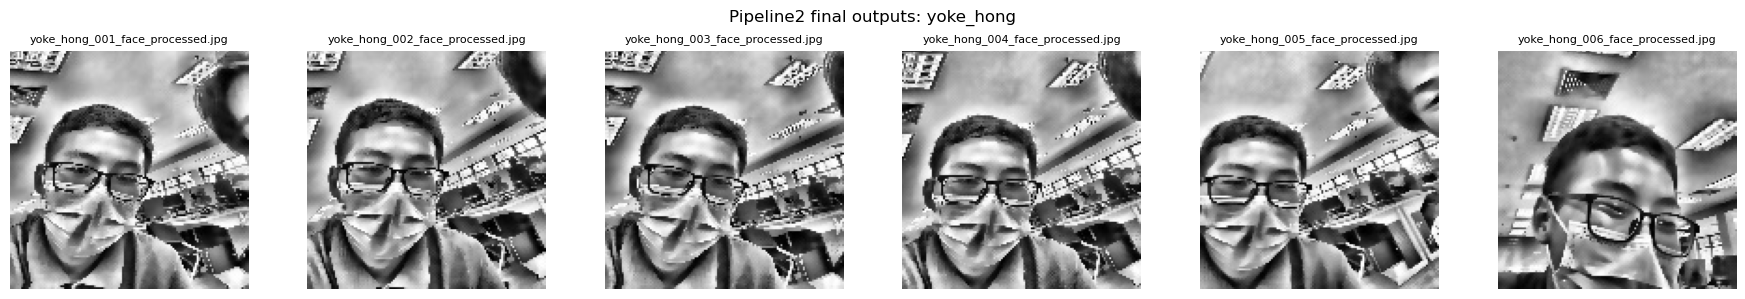

{'conversion': {'processed': 478,
  'saved': 426,
  'blurry': 52,
  'failed': 0,
  'per_person': {'benjamin': 39,
   'chern_tak': 36,
   'chillien': 7,
   'daniel': 47,
   'dylan': 32,
   'han_soon': 11,
   'harry': 19,
   'isaac': 10,
   'jing_ang': 9,
   'jun_wei': 8,
   'kang_kai': 16,
   'marion': 9,
   'nurul': 11,
   'qi_xuan': 11,
   'shuang_quan': 46,
   'wee_xuan': 16,
   'xiang_yue': 14,
   'xu_sheng': 12,
   'yoke_hong': 49,
   'yong_kang': 13,
   'zi_herng': 11}},
 'alignment': {'processed': 426,
  'saved': 395,
  'failed': 31,
  'aligned': 173,
  'per_person': {'benjamin': 36,
   'chern_tak': 35,
   'chillien': 6,
   'daniel': 41,
   'dylan': 32,
   'han_soon': 9,
   'harry': 15,
   'isaac': 10,
   'jing_ang': 9,
   'jun_wei': 8,
   'kang_kai': 15,
   'marion': 9,
   'nurul': 11,
   'qi_xuan': 11,
   'shuang_quan': 40,
   'wee_xuan': 13,
   'xiang_yue': 14,
   'xu_sheng': 12,
   'yoke_hong': 46,
   'yong_kang': 13,
   'zi_herng': 10}},
 'final': {'processed': 395,
  'saved

In [ ]:
smoke_test_stats = run_complete_pipeline2(people=None, publish=False)
preview_pipeline2_samples()
smoke_test_stats

In [ ]:
run_complete_pipeline2(people=['benjamin'], publish=False, clean=True)


STEP 1: STANDARDIZE RAW IMAGES

Processing benjamin (41 files)
  skipped blurry image: IMG_1929.JPG (score=34.3)
  skipped blurry image: IMG_E1929.JPG (score=32.5)
  saved 39 standardized images

Standardization summary
  processed: 41
  saved:     39
  blurry:    2
  failed:    0
STEP 2: DETECT, ALIGN, AND CROP LARGEST FACE

Aligning benjamin (39 files)
  no face kept: benjamin_029.jpg
  no face kept: benjamin_030.jpg
  no face kept: benjamin_041.jpg
  saved 36 aligned face crops

Alignment summary
  processed: 39
  saved:     36
  aligned:   16
  failed:    3
STEP 3: ENHANCE ALIGNED FACES FOR LBPH

Enhancing benjamin (36 crops)
  saved 36 LBPH-ready faces

LBPH post-processing summary
  processed: 36
  saved:     36
  failed:    0
STEP 4: CREATE LBPH-COMPATIBLE AUGMENTED DATASET
Target images per person: 100
  benjamin: 36 originals + 64 augmented = 100

Augmentation summary
  originals: 36
  augmented: 64
  total:     100

Pipeline2 complete
Elapsed time: 20.5 seconds
PIPELINE2 OUTP

{'conversion': {'processed': 41,
  'saved': 39,
  'blurry': 2,
  'failed': 0,
  'per_person': {'benjamin': 39}},
 'alignment': {'processed': 39,
  'saved': 36,
  'failed': 3,
  'aligned': 16,
  'per_person': {'benjamin': 36}},
 'final': {'processed': 36,
  'saved': 36,
  'failed': 0,
  'per_person': {'benjamin': 36}},
 'augmentation': {'originals': 36,
  'augmented': 64,
  'per_person': {'benjamin': {'originals': 36,
    'augmented': 64,
    'total': 100}}},
 'publish': None,
 'elapsed_seconds': 20.509074926376343}

In [ ]:
import types

def expanded_crop_face(self, image, face_location, strict_padding=False):
    top, right, bottom, left = face_location
    img_h, img_w = image.shape[:2]
    height = bottom - top
    width = right - left

    pad_x = int(round(width * (FACE_PADDING_X + (0.08 if strict_padding else 0.0))))
    pad_top = int(round(height * (FACE_PADDING_TOP + (0.10 if strict_padding else 0.0))))
    pad_bottom = int(round(height * (FACE_PADDING_BOTTOM + (0.14 if strict_padding else 0.0))))

    x1 = left - pad_x
    x2 = right + pad_x
    y1 = top - pad_top
    y2 = bottom + pad_bottom

    crop_w = x2 - x1
    crop_h = y2 - y1
    desired = max(crop_w, crop_h)

    bbox_area_ratio = (width * height) / float(max(1, img_w * img_h))
    if bbox_area_ratio > 0.35:
        min_context = int(round(min(img_w, img_h) * 0.6))
        if desired < min_context:
            desired = min_context

    desired = min(desired, max(img_w, img_h))

    center_x = (x1 + x2) / 2.0
    center_y = (y1 + y2) / 2.0
    new_x1 = int(round(center_x - desired / 2.0))
    new_x2 = int(round(center_x + desired / 2.0))
    new_y1 = int(round(center_y - desired / 2.0))
    new_y2 = int(round(center_y + desired / 2.0))

    if new_x1 < 0:
        new_x2 = min(img_w, new_x2 - new_x1)
        new_x1 = 0
    if new_y1 < 0:
        new_y2 = min(img_h, new_y2 - new_y1)
        new_y1 = 0
    if new_x2 > img_w:
        shift = new_x2 - img_w
        new_x1 = max(0, new_x1 - shift)
        new_x2 = img_w
    if new_y2 > img_h:
        shift = new_y2 - img_h
        new_y1 = max(0, new_y1 - shift)
        new_y2 = img_h

    if new_x2 <= new_x1 or new_y2 <= new_y1:
        return np.array([]), (0, 0, 0, 0)

    return image[new_y1:new_y2, new_x1:new_x2], (new_x1, new_y1, new_x2, new_y2)

aligner.crop_face = types.MethodType(expanded_crop_face, aligner)
print('aligner.crop_face patched to expand close-up faces')


aligner.crop_face patched to expand close-up faces
